# ACP de la banque d'aliments — cours de rappel

Ce notebook **reproduit à la main** la carte ACP de l'app (onglet *Comparer → Carte ACP*) et
déroule les diagnostics classiques d'une analyse en composantes principales, sur **nos** aliments et
nutriments. Objectif : comprendre / réviser.

On répond notamment à : *quels nutriments comptent pour combien dans PC1, PC2, PC3, PC4 ?*, *quelle
variance chaque axe explique ?*, *comment est construit un biplot (aliments **et** nutriments sur la
même carte) ?* et *pourquoi presque tous les aliments sont près du centre alors que les flèches vont
loin — sauf les épinards ?*

**Réglages, identiques à l'app par défaut :** base **pour 100 kcal**, nutriments **standardisés**
(z-score) puis **pondérés** par l'importance, **compléments exclus**.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)

# ---- Réglages (à jouer) --------------------------------------------------
BASE = "100kcal"      # "100kcal" (défaut app) ou "100g"
WEIGHTED = True        # pondérer par l'importance (défaut app)
EXCLUDE_SUPPLEMENTS = True

foods = pd.read_csv("data/foods.csv")
nutri = pd.read_csv("data/nutrients.csv")

# Couleurs de catégorie (mêmes que l'app) pour retrouver ses repères.
CAT_COLOR = {
    "fruit": "#ef6f6f", "legume": "#3ecf8e", "feculent": "#f5a623", "viande": "#c8603f",
    "poisson": "#5b8cff", "oeuf-laitier": "#e3c65b", "sucre-snack": "#d16ba5",
    "matiere-grasse": "#8ac926", "boisson": "#4dc9d0", "plat": "#a58bff",
    "supplement": "#7a7f8a", "autre": "#9aa2b1",
}
print(f"{len(foods)} aliments, {len(nutri)} nutriments (dont kcal)")
foods.head(3)

148 aliments, 35 nutriments (dont kcal)


,id,nom,categorie,kcal,proteines,glucides,lipides,fibres,agSatures,agTrans,agMonoInsatures,agPolyInsatures,omega3,omega6,omega9,fer,magnesium,potassium,calcium,zinc,sodium,selenium,iode,vitA,vitC,vitD,vitE,vitK1,vitK2,vitB1,vitB2,vitB3,vitB5,vitB6,vitB9,vitB12,creatine,collagene
0,banane,Banane,fruit,90.0,0.9,20.0,0.3,2.6,0.1,0.0,0.0,0.0,0.0,0.0,0.0,0.3,28,360,5,0.2,1,1.0,0,3,9.0,0.0,0.3,0.5,0,0.03,0.07,0.70,0.33,0.37,20,0.0,0.0,0.0
1,pomme,Pomme,fruit,52.0,0.3,12.0,0.2,2.4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.1,5,107,6,0.0,1,0.0,0,3,4.6,0.0,0.2,2.0,0,0.02,0.03,0.09,0.06,0.04,3,0.0,0.0,0.0
2,poire,Poire,fruit,57.0,0.4,12.0,0.1,3.1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7,116,9,0.0,0,0.0,0,0,4.0,0.0,0.0,4.4,0,0.01,0.03,0.16,0.05,0.03,7,0.0,0.0,0.0


## 1. Construire la matrice « aliments × nutriments »

On part des valeurs **pour 100 g**, on passe en **densité par calorie** (`valeur × 100 / kcal`) — c'est
la base de l'app —, on retire les **calories** (constantes par 100 kcal) et les **compléments**
(produits ultra-concentrés qui écraseraient les axes).

In [ ]:
NUT_KEYS = [k for k in nutri["key"].tolist() if k != "kcal"]      # 34 nutriments
LABEL = dict(zip(nutri["key"], nutri["label"]))
UNIT = dict(zip(nutri["key"], nutri["unit"]))
GROUP = dict(zip(nutri["key"], nutri["group"]))
IMPORTANCE = dict(zip(nutri["key"], nutri["importance"]))

df = foods.copy()
if EXCLUDE_SUPPLEMENTS:
    df = df[df["categorie"] != "supplement"].reset_index(drop=True)

def normalize(row):
    if BASE == "100g":
        return row[NUT_KEYS].astype(float)
    kcal = row["kcal"]
    factor = (100.0 / kcal) if kcal > 0 else 0.0
    return row[NUT_KEYS].astype(float) * factor

X = df.apply(normalize, axis=1)
X.index = df["nom"]
print("Matrice X :", X.shape, f"(base {BASE})")
X.iloc[:4, :6].round(2)

Matrice X : (133, 34) (base 100kcal)


,proteines,glucides,lipides,fibres,agSatures,agTrans
nom,,,,,,
Banane,1.00,22.22,0.33,2.89,0.11,0.0
Pomme,0.58,23.08,0.38,4.62,0.00,0.0
Poire,0.70,21.05,0.18,5.44,0.00,0.0
Abricot,2.92,18.75,0.83,4.17,0.00,0.0


## 2. Standardiser (z-score) puis pondérer

Les nutriments ont des unités incomparables (potassium en centaines de mg, vitamine D en µg). On
**standardise** chaque colonne : `z = (x − moyenne) / écart-type`. Chaque nutriment a alors moyenne 0,
écart-type 1 → ils pèsent pareil. C'est une **ACP de corrélation**.

On multiplie ensuite chaque colonne par `√importance` : dans une distance au carré, `(√w·z)² = w·z²`,
donc le nutriment pèse `w` (importance) dans les axes. *(écart-type de population, ÷n, comme l'app.)*

In [ ]:
mean = X.mean(axis=0)
std = X.std(axis=0, ddof=0)                      # population (÷n), comme l'app
Z = (X - mean) / std.replace(0, np.nan)
Z = Z.fillna(0.0)                                 # colonne constante -> neutralisée

if WEIGHTED:
    w = np.array([IMPORTANCE[k] for k in NUT_KEYS], dtype=float)
else:
    w = np.ones(len(NUT_KEYS))
Zw = Z.values * np.sqrt(np.clip(w, 0, None))

print("Nutriments pondérés (importance ≠ 1) :",
      {LABEL[k]: IMPORTANCE[k] for k in NUT_KEYS if IMPORTANCE[k] != 1})
print("Zw :", Zw.shape)

Nutriments pondérés (importance ≠ 1) : {'Oméga 3': 1.5, 'Vitamine D': 1.3, 'Créatine': 0.4, 'Collagène': 0.6}
Zw : (133, 34)


## 3. L'ACP par SVD + variance expliquée par PC1, PC2, PC3…

Une ACP = décomposition en valeurs singulières `Zw = U · S · Vᵀ`. Les **valeurs singulières** `S`
donnent la variance de chaque axe (`λ = S²/n`), les colonnes de **V** sont les directions
(*loadings*), `U·S` sont les **coordonnées** des aliments (*scores*).

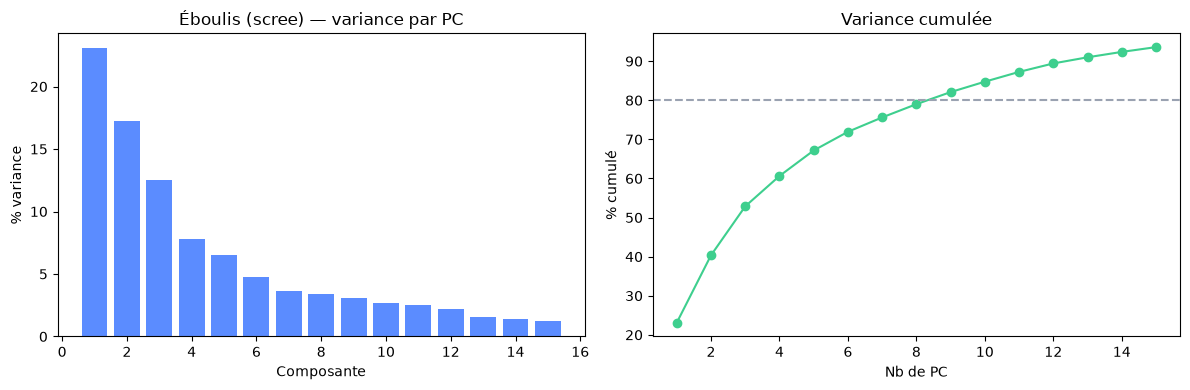

,PC,variance %,cumulé %
0,PC1,23.1,23.1
1,PC2,17.2,40.3
2,PC3,12.5,52.9
3,PC4,7.8,60.6
4,PC5,6.5,67.2
5,PC6,4.8,71.9
6,PC7,3.7,75.6
7,PC8,3.4,79.0


In [ ]:
n = Zw.shape[0]
U, S, Vt = np.linalg.svd(Zw, full_matrices=False)
eig = (S ** 2) / n                                # variance par composante
explained = eig / eig.sum()                       # part de variance expliquée

# Signe arbitraire en ACP : on oriente PC1 pour que la majorité des nutriments soit positive,
# PC2 pour que « protéines » soit positif — juste pour coller à la carte de l'app.
if Vt[0].sum() < 0:
    Vt[0] *= -1; U[:, 0] *= -1
pidx = NUT_KEYS.index("proteines")
if Vt[1][pidx] < 0:
    Vt[1] *= -1; U[:, 1] *= -1

scores = U * S                                     # coordonnées des aliments (n × k)
loadings = Vt.T * np.sqrt(eig)                     # flèches « √λ », comme l'app (m × k)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
k = min(15, len(explained))
ax[0].bar(np.arange(1, k + 1), explained[:k] * 100, color="#5b8cff")
ax[0].set(title="Éboulis (scree) — variance par PC", xlabel="Composante", ylabel="% variance")
ax[1].plot(np.arange(1, k + 1), np.cumsum(explained[:k]) * 100, "-o", color="#3ecf8e")
ax[1].axhline(80, ls="--", c="#9aa2b1"); ax[1].set(title="Variance cumulée", xlabel="Nb de PC", ylabel="% cumulé")
plt.tight_layout(); plt.show()

pd.DataFrame({
    "PC": [f"PC{i+1}" for i in range(8)],
    "variance %": (explained[:8] * 100).round(1),
    "cumulé %": (np.cumsum(explained[:8]) * 100).round(1),
})

La carte 2D de l'app = **PC1 + PC2**. Regarde le cumulé : c'est l'« honnêteté » de la carte (l'app
affiche l'avertissement *« carte approximative »* sous ~50 %). Les PC3, PC4… portent le reste.

## 4. Quels nutriments comptent pour combien dans PC1, PC2, PC3, PC4 ?

Deux lectures d'un axe :
- le **loading** (signe + amplitude) : dans quel sens et combien un nutriment tire l'axe ;
- la **contribution %** = `loading² / Σ loading²` : la part de l'axe portée par ce nutriment (somme = 100 %).

In [ ]:
V = Vt.T                                            # directions unitaires (m × k)
contrib = (V ** 2)                                 # colonnes déjà normées -> somme = 1 par PC
load_df = pd.DataFrame(V[:, :4], index=[LABEL[k] for k in NUT_KEYS],
                       columns=["PC1", "PC2", "PC3", "PC4"])

def top_axis(i, n=8):
    s = load_df.iloc[:, i]
    t = s.reindex(s.abs().sort_values(ascending=False).index).head(n)
    return pd.DataFrame({
        f"PC{i+1} loading": t.round(3),
        "contrib %": (t.values ** 2 * 100).round(1),
    })

for i in range(4):
    print(f"\n=== PC{i+1} — {explained[i]*100:.1f} % de variance — nutriments dominants ===")
    print(top_axis(i).to_string())


=== PC1 — 23.1 % de variance — nutriments dominants ===
             PC1 loading  contrib %
Vitamine B9        0.308        9.5
Potassium          0.307        9.4
Vitamine K1        0.264        7.0
Fibres             0.263        6.9
Vitamine B6        0.260        6.8
Magnésium          0.244        5.9
Vitamine A         0.224        5.0
Vitamine B1        0.222        4.9

=== PC2 — 17.2 % de variance — nutriments dominants ===
                  PC2 loading  contrib %
Protéines               0.329       10.8
Glucides               -0.313        9.8
Vitamine B12            0.298        8.9
Vitamine D              0.294        8.7
Oméga 3                 0.293        8.6
Sélénium                0.287        8.2
Vitamine B3 (PP)        0.261        6.8
Collagène               0.194        3.8

=== PC3 — 12.5 % de variance — nutriments dominants ===
                   PC3 loading  contrib %
Lipides                 -0.323       10.4
AG mono-insaturés       -0.301        9.0
Oméga 9   

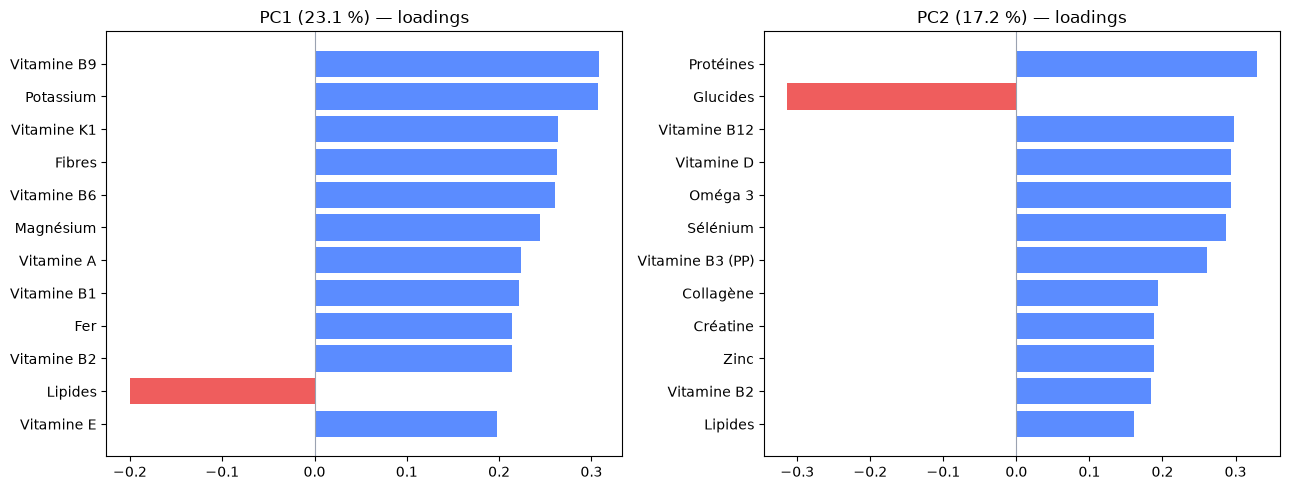

In [ ]:
# Barres : top contributeurs de PC1 et PC2 (signe = sens de l'axe)
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
for i, a in enumerate(ax):
    s = load_df.iloc[:, i]
    s = s.reindex(s.abs().sort_values().index).tail(12)
    a.barh(s.index, s.values, color=["#ef5d5d" if v < 0 else "#5b8cff" for v in s.values])
    a.axvline(0, c="#9aa2b1", lw=.8); a.set_title(f"PC{i+1} ({explained[i]*100:.1f} %) — loadings")
plt.tight_layout(); plt.show()

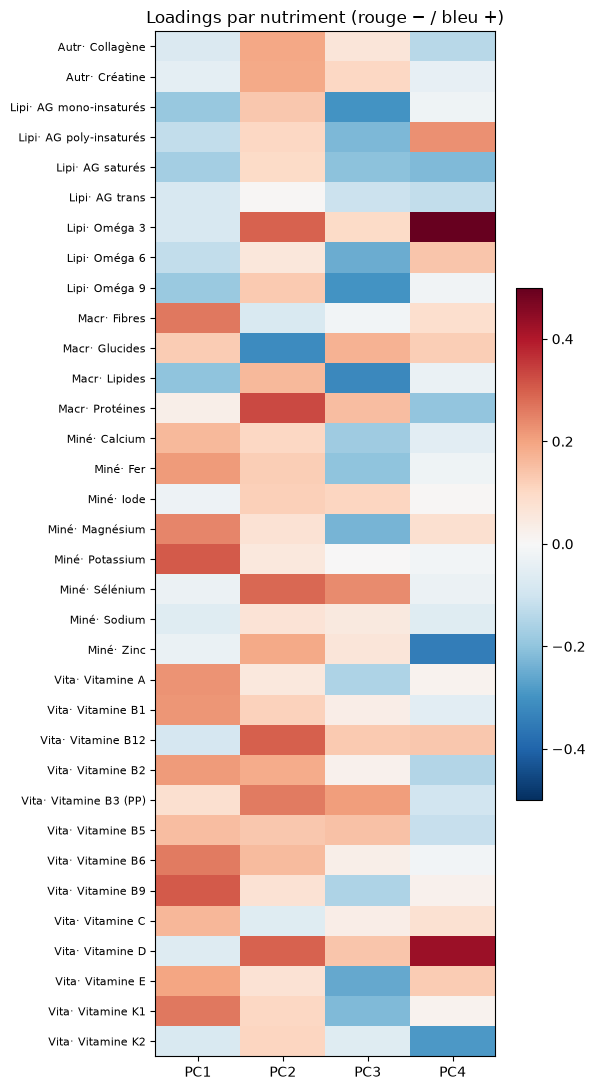

In [ ]:
# Heatmap loadings PC1..PC4 (regroupés par famille de nutriments)
order = sorted(range(len(NUT_KEYS)), key=lambda j: (GROUP[NUT_KEYS[j]], NUT_KEYS[j]))
H = V[order, :4]
labels = [f"{GROUP[NUT_KEYS[j]][:4]}· {LABEL[NUT_KEYS[j]]}" for j in order]
fig, a = plt.subplots(figsize=(6, 11))
im = a.imshow(H, cmap="RdBu_r", vmin=-0.5, vmax=0.5, aspect="auto")
a.set_xticks(range(4)); a.set_xticklabels(["PC1", "PC2", "PC3", "PC4"])
a.set_yticks(range(len(labels))); a.set_yticklabels(labels, fontsize=8)
a.set_title("Loadings par nutriment (rouge − / bleu +)"); fig.colorbar(im, shrink=.5)
plt.tight_layout(); plt.show()

## 5. Le biplot : aliments **et** nutriments sur la même carte

Un biplot superpose deux nuages qui vivent dans des espaces **duaux** :
- les **aliments** (lignes) = `F = U · Sᵃ`
- les **nutriments** (colonnes / flèches) = `G = V · S¹⁻ᵃ`

Le paramètre **α ∈ [0,1]** répartit les valeurs singulières entre les deux :
- **α = 1** → *biplot des distances* : les distances entre aliments ≈ vraies distances (euclidiennes) ;
- **α = 0** → *biplot des corrélations* : les **angles** entre flèches ≈ corrélations entre nutriments,
  et la **longueur** d'une flèche ≈ sa qualité de représentation en 2D.

L'app, elle, place les aliments en `U·S` (α=1) et les flèches en `V·√λ`, **puis rééchelonne
visuellement** les flèches pour qu'elles remplissent le cadre (d'où leur longueur — voir §6).

C:\Users\romai\AppData\Local\Temp\ipykernel_29052\796220974.py:25: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(); plt.show()


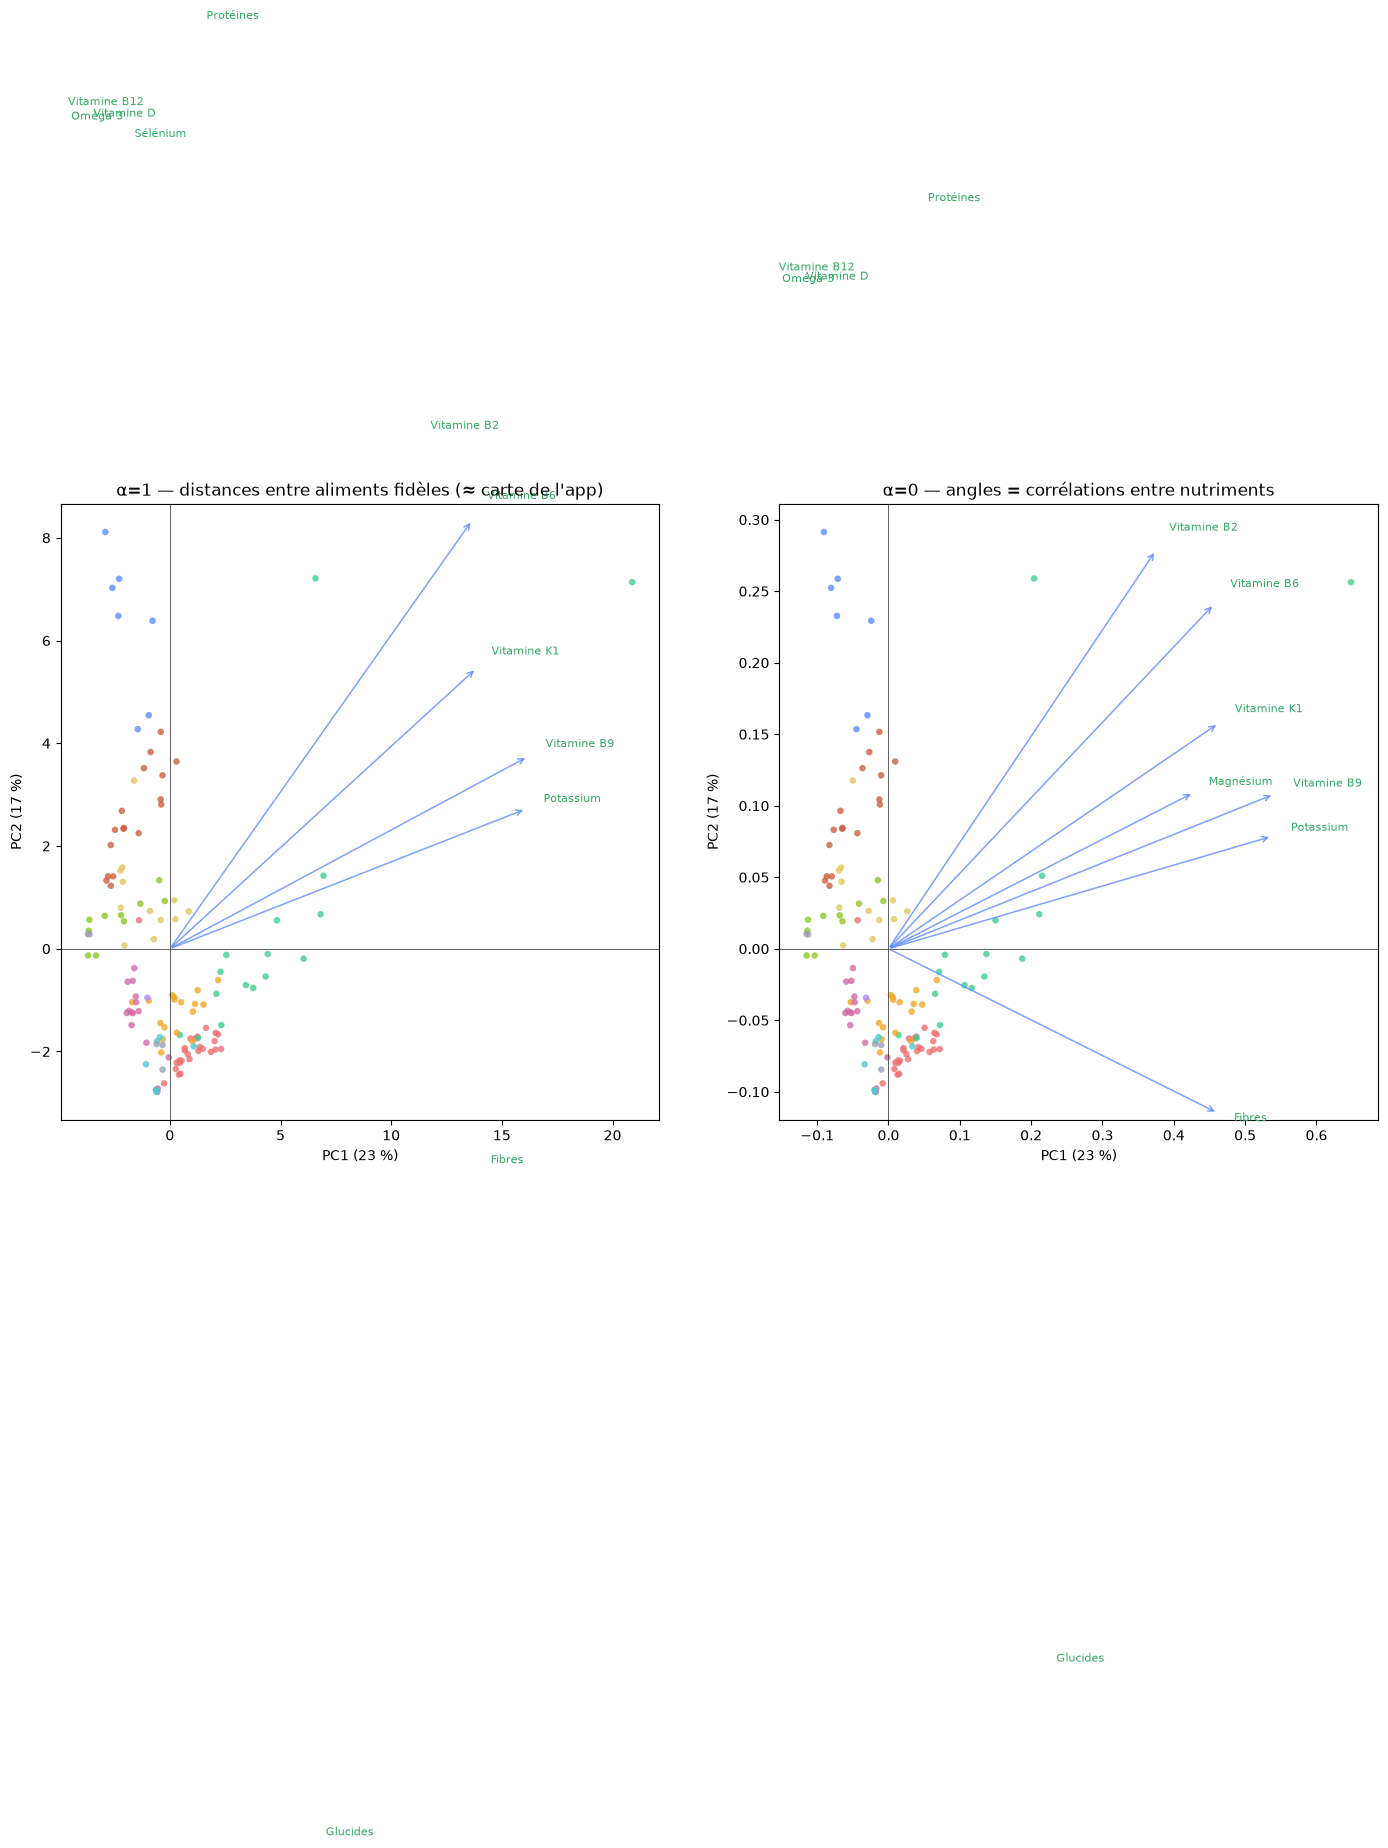

In [ ]:
def biplot(alpha=1.0, title="", arrow_scale=None, ax=None, n_arrows=12):
    if ax is None:
        _, ax = plt.subplots(figsize=(9, 8))
    F = U[:, :2] * (S[:2] ** alpha)
    G = V[:, :2] * (S[:2] ** (1 - alpha))
    if arrow_scale is None:
        # rééchelonnage « façon app » : la plus longue flèche ≈ 0.85 × le point le plus loin
        arrow_scale = 0.85 * np.max(np.abs(F)) / max(1e-9, np.max(np.hypot(G[:, 0], G[:, 1])))
    Ga = G * arrow_scale
    cols = df["categorie"].map(CAT_COLOR).fillna("#9aa2b1").values
    ax.scatter(F[:, 0], F[:, 1], c=cols, s=22, alpha=.8, edgecolor="none")
    ax.axhline(0, c="#444", lw=.6); ax.axvline(0, c="#444", lw=.6)
    imp = np.hypot(Ga[:, 0], Ga[:, 1])
    for j in np.argsort(imp)[::-1][:n_arrows]:
        ax.annotate("", xy=(Ga[j, 0], Ga[j, 1]), xytext=(0, 0),
                    arrowprops=dict(arrowstyle="->", color="#5b8cff", lw=1.1, alpha=.8))
        ax.text(Ga[j, 0]*1.05, Ga[j, 1]*1.05, LABEL[NUT_KEYS[j]], color="#3a6", fontsize=8)
    ax.set(title=title or f"Biplot (α={alpha})",
           xlabel=f"PC1 ({explained[0]*100:.0f} %)", ylabel=f"PC2 ({explained[1]*100:.0f} %)")
    return ax

fig, ax = plt.subplots(1, 2, figsize=(17, 8))
biplot(alpha=1.0, title="α=1 — distances entre aliments fidèles (≈ carte de l'app)", ax=ax[0])
biplot(alpha=0.0, title="α=0 — angles = corrélations entre nutriments", ax=ax[1])
plt.tight_layout(); plt.show()

## 6. Pourquoi les aliments sont-ils au centre et les flèches loin — sauf les épinards ?

Trois effets se cumulent :

1. **La standardisation tasse la majorité au centre.** Après z-score, l'aliment « moyen » est en 0.
   La plupart des aliments sont proches de la moyenne → ils s'entassent près de l'origine.
2. **La base « pour 100 kcal » crée des extrêmes.** Un aliment très **peu calorique mais riche en
   micronutriments** (épinards, cresson, persil…) explose en densité par calorie → score énorme.
   Ces quelques outliers étirent les axes.
3. **Les flèches sont rééchelonnées pour remplir le cadre** (facteur `0.85 × score_max / flèche_max`
   dans l'app). Elles sont donc calées sur **l'aliment le plus lointain** — souvent les épinards. D'où
   l'illusion : tout paraît « petit » à l'intérieur, et seules les flèches (et l'outlier) touchent les bords.

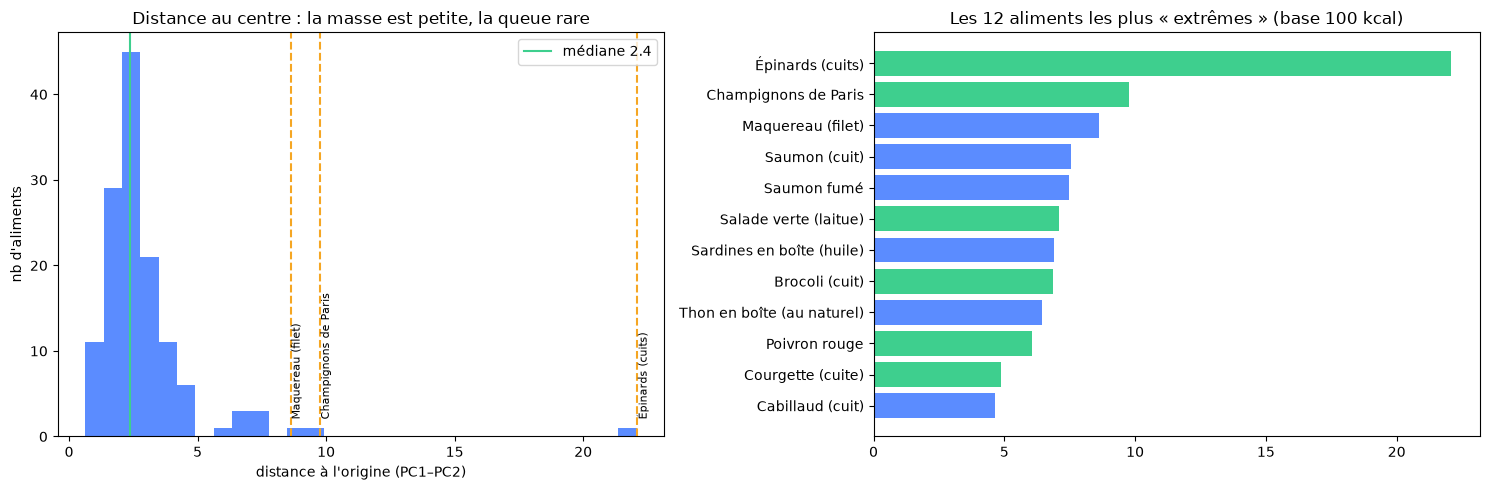

,nom,categorie,dist_centre,PC1,PC2
0,Épinards (cuits),legume,22.08,20.89,7.14
1,Champignons de Paris,legume,9.76,6.58,7.21
2,Maquereau (filet),poisson,8.62,-2.92,8.11
3,Saumon (cuit),poisson,7.56,-2.29,7.20
4,Saumon fumé,poisson,7.49,-2.60,7.03
5,Salade verte (laitue),legume,7.09,6.94,1.42
6,Sardines en boîte (huile),poisson,6.89,-2.33,6.48
7,Brocoli (cuit),legume,6.85,6.81,0.67
8,Thon en boîte (au naturel),poisson,6.43,-0.78,6.39
9,Poivron rouge,legume,6.05,6.04,-0.19


In [ ]:
F = U[:, :2] * S[:2]
norms = np.hypot(F[:, 0], F[:, 1])
extreme = pd.DataFrame({"nom": df["nom"].values, "categorie": df["categorie"].values,
                        "dist_centre": norms.round(2),
                        "PC1": F[:, 0].round(2), "PC2": F[:, 1].round(2)})
top = extreme.sort_values("dist_centre", ascending=False).head(12)

fig, ax = plt.subplots(1, 2, figsize=(15, 5))
ax[0].hist(norms, bins=30, color="#5b8cff")
med = np.median(norms)
ax[0].axvline(med, c="#3ecf8e", label=f"médiane {med:.1f}")
for _, r in top.head(3).iterrows():
    ax[0].axvline(r["dist_centre"], c="#f5a623", ls="--")
    ax[0].text(r["dist_centre"], 2, r["nom"], rotation=90, va="bottom", fontsize=8)
ax[0].set(title="Distance au centre : la masse est petite, la queue rare",
          xlabel="distance à l'origine (PC1–PC2)", ylabel="nb d'aliments"); ax[0].legend()

ax[1].barh(top["nom"][::-1], top["dist_centre"][::-1],
           color=top["categorie"][::-1].map(CAT_COLOR).fillna("#9aa2b1"))
ax[1].set(title="Les 12 aliments les plus « extrêmes » (base 100 kcal)")
plt.tight_layout(); plt.show()
top.reset_index(drop=True)

> Change `BASE = "100g"` tout en haut et relance : les épinards rentrent dans le rang (ils ne sont
> plus dopés par leur faible densité calorique), et d'autres aliments deviennent les extrêmes. La
> « forme » de la carte **dépend de la base** — un point clé pour ne pas sur-interpréter.

## 7. Diagnostics classiques : qualité de représentation (cos²) et contributions

- **cos²** d'un aliment = part de son profil réellement **capturée par le plan** PC1–PC2 (0→1). Un
  point à faible cos² est **mal représenté** : il paraît quelconque en 2D mais peut être extrême sur
  PC3+. *(C'est exactement ce qu'on veut estomper dans l'app — l'item « interprétation sans erreur ».)*
- **contribution** d'un aliment à un axe = combien il pèse dans la construction de cet axe.

Mieux représentés en 2D :
                  nom   categorie  cos2_PC12
Biscuits petit-beurre sucre-snack       0.78
               Cookie sucre-snack       0.75
     Épinards (cuits)      legume       0.74
                Pomme       fruit       0.73
               Cerise       fruit       0.72
     Compote de pomme       fruit       0.71

Mal représentés (à ne pas sur-interpréter au centre) :
             nom      categorie  cos2_PC12
            Skyr   oeuf-laitier       0.02
 Graines de chia matiere-grasse       0.03
   Yaourt nature   oeuf-laitier       0.03
Lait demi-écrémé   oeuf-laitier       0.03
Fromage blanc 0%   oeuf-laitier       0.05
  Graines de lin matiere-grasse       0.05


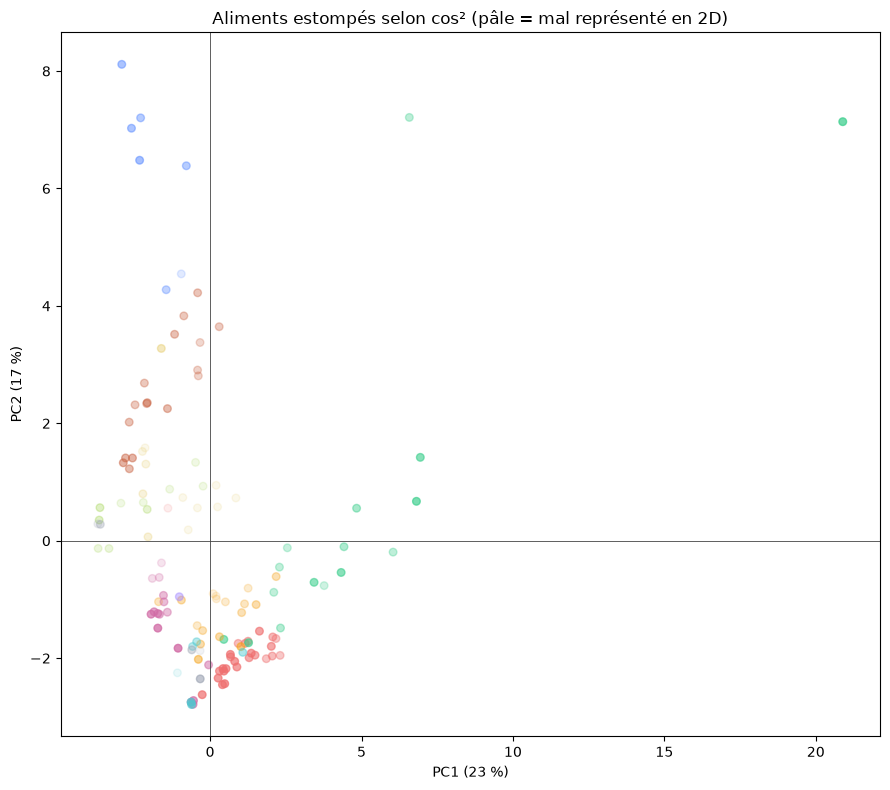

In [ ]:
row_sq = (U * S) ** 2                              # (n × k)
total_row = row_sq.sum(axis=1)                     # inertie totale par aliment
cos2_plane = row_sq[:, :2].sum(axis=1) / np.clip(total_row, 1e-12, None)

diag = pd.DataFrame({"nom": df["nom"].values, "categorie": df["categorie"].values,
                     "cos2_PC12": cos2_plane.round(2)})
print("Mieux représentés en 2D :"); print(diag.sort_values("cos2_PC12", ascending=False).head(6).to_string(index=False))
print("\nMal représentés (à ne pas sur-interpréter au centre) :")
print(diag.sort_values("cos2_PC12").head(6).to_string(index=False))

# Nuage estompé par cos² (aperçu de la future feature de l'app)
fig, a = plt.subplots(figsize=(9, 8))
cols = df["categorie"].map(CAT_COLOR).fillna("#9aa2b1").values
a.scatter(F[:, 0], F[:, 1], c=cols, s=30, alpha=np.clip(cos2_plane, .12, 1))
a.axhline(0, c="#444", lw=.6); a.axvline(0, c="#444", lw=.6)
a.set(title="Aliments estompés selon cos² (pâle = mal représenté en 2D)",
      xlabel=f"PC1 ({explained[0]*100:.0f} %)", ylabel=f"PC2 ({explained[1]*100:.0f} %)")
plt.tight_layout(); plt.show()

## 8. Autres projections 2D : t-SNE et MDS (quand l'ACP ne suffit pas)

L'ACP est **linéaire** : chaque axe est une combinaison des nutriments (d'où les flèches
interprétables). Mais si la « vraie » structure des aliments est **courbe** dans l'espace à 34
dimensions, deux méthodes non linéaires la révèlent mieux :

- **t-SNE** : garde surtout les **voisinages locaux** → excellent pour faire **ressortir des grappes**
  (familles d'aliments). En contrepartie : les **distances entre grappes et leurs tailles ne veulent
  rien dire**, le résultat est **aléatoire** (graine + *perplexity*), et il n'y a **ni axes ni flèches**.
- **MDS** (métrique) : cherche à **préserver les distances par paires**. Sur des profils standardisés,
  c'est proche de l'ACP mais sans flèches — une carte « distance-fidèle ».

On les calcule sur **la même matrice** `Zw` (standardisée + pondérée) que l'ACP, pour comparer à armes égales.

C:\Users\romai\Desktop\Prog\FoodRecorder\analysis\.venv\Lib\site-packages\sklearn\manifold\_mds.py:735: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(


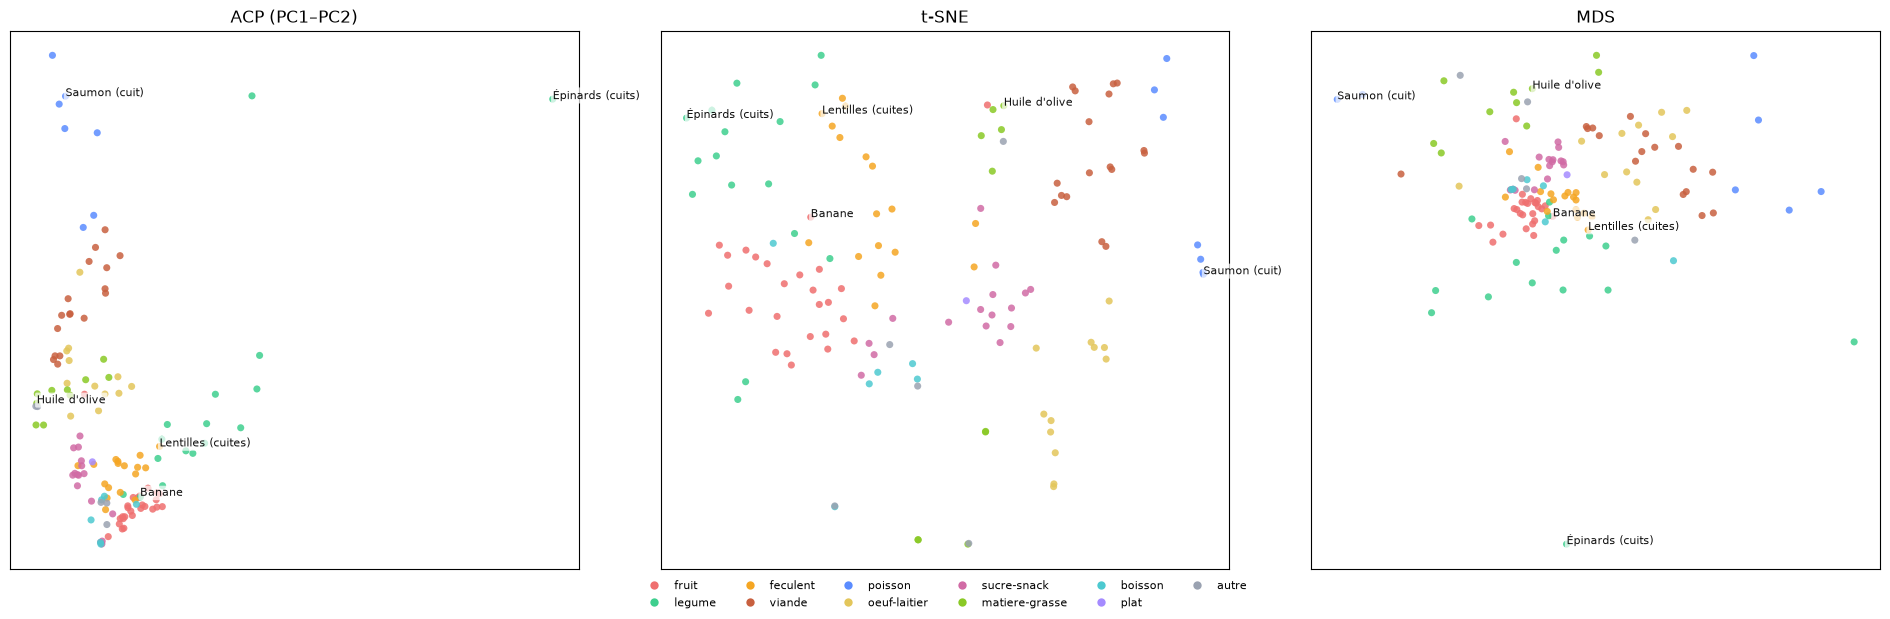

In [ ]:
from sklearn.manifold import TSNE, MDS

tsne = TSNE(n_components=2, perplexity=30, init="pca",
            learning_rate="auto", random_state=0).fit_transform(Zw)
mds = MDS(n_components=2, random_state=0, normalized_stress="auto").fit_transform(Zw)

embeds = [("ACP (PC1–PC2)", scores[:, :2]), ("t-SNE", tsne), ("MDS", mds)]
cols = df["categorie"].map(CAT_COLOR).fillna("#9aa2b1").values
tags = ["Épinards (cuits)", "Banane", "Saumon (cuit)", "Huile d'olive", "Sucre blanc", "Lentilles (cuites)"]
name_to_i = {n: i for i, n in enumerate(df["nom"])}

fig, ax = plt.subplots(1, 3, figsize=(19, 6.2))
for a, (title, E) in zip(ax, embeds):
    a.scatter(E[:, 0], E[:, 1], c=cols, s=26, alpha=.85, edgecolor="none")
    for t in tags:
        i = name_to_i.get(t)
        if i is not None:
            a.annotate(t, (E[i, 0], E[i, 1]), fontsize=8, color="#111",
                       bbox=dict(boxstyle="round,pad=.15", fc="white", ec="none", alpha=.7))
    a.set_title(title); a.set_xticks([]); a.set_yticks([])
handles = [plt.Line2D([0], [0], marker="o", ls="", mfc=c, mec="none",
                      label=k) for k, c in CAT_COLOR.items() if k != "supplement"]
fig.legend(handles=handles, loc="lower center", ncol=6, fontsize=8, frameon=False)
plt.tight_layout(rect=(0, 0.05, 1, 1)); plt.show()

### Comment les lire (et leurs pièges)

| | ACP | t-SNE | MDS |
|---|---|---|---|
| Nature | linéaire | non linéaire (voisinages) | distances |
| Axes interprétables | **oui** (flèches nutriments) | non | non |
| Distances fiables | globales, approx. | **non** (local seulement) | **oui** (par paires) |
| Grappes nettes | moyennes | **très nettes** | moyennes |
| Reproductible | oui | non (graine/perplexity) | ~oui |
| Projeter un **nouvel** aliment | **oui** (produit matriciel) | non | non |

Sur nos données, les trois séparent nettement les **fruits/sucré** (tirés par glucides + vit C) des
**viandes/poissons** (protéines, B12, D) et des **matières grasses**. Le t-SNE resserre chaque famille
en paquets ; l'ACP et le MDS gardent des transitions continues (un aliment « à mi-chemin » reste au milieu).

### À quoi ça sert, concrètement, pour un utilisateur

- **t-SNE / (UMAP)** — repérer d'un coup d'œil les **familles** d'aliments et les **intrus** : un aliment
  posé loin de sa couleur de catégorie = profil atypique **ou erreur de saisie** à corriger. Utile aussi
  pour **auditer la diversité de ton assiette** (si tes aliments habituels forment un seul paquet, tu
  rates les nutriments des paquets voisins).
- **MDS** — quand tu veux une carte où la **proximité = vraie ressemblance** (distances honnêtes), sans
  te soucier des axes. Bon pour juger « est-ce que A et B se ressemblent *vraiment* ? ».
- **ACP** — la seule qui dit **pourquoi** (les flèches = nutriments) et qui sait **placer un aliment
  nouveau/perso** sans tout recalculer. C'est pour ça que l'app l'a choisie comme carte principale ;
  t-SNE/MDS sont des **compléments d'exploration**.

> Astuce t-SNE : change `perplexity` (5 → très local/plein de petits paquets ; 50 → plus global) et la
> `random_state` — si les grappes bougent beaucoup, c'est le signe qu'il ne faut pas sur-interpréter leur forme.

## 9. Récap — comment ça se relie à l'app

- La carte de l'app = **PC1 × PC2** de cette même ACP (base 100 kcal, standardisée, pondérée).
- Les **flèches** = les *loadings* (§4) ; leur longueur affichée est rééchelonnée (§6).
- La **variance expliquée** affichée = `explained[0] + explained[1]` (§3) ; sous ~50 %, prudence.
- Deux aliments **proches** ont des profils proches — *à la qualité (cos²) près* (§7).

**À jouer :** `BASE`, `WEIGHTED`, `EXCLUDE_SUPPLEMENTS` en tête de notebook, puis *Run All*. Regarde
comme la carte, les loadings et les extrêmes bougent — c'est le meilleur moyen de sentir ce que fait
(et ne fait pas) une ACP.